<a href="https://colab.research.google.com/github/SophiaPeritz/pinn-turbolence/blob/main/notebooks/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Monta Drive per salvare i checkpoint
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/pinn-turbulence-results'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Cartella risultati: {DRIVE_DIR}")

# Clona la repo (la prima volta)
!git clone https://github.com/SophiaPeritz/pinn-turbolence.git
%cd pinn-turbolence

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cartella risultati: /content/drive/MyDrive/pinn-turbulence-results
Cloning into 'pinn-turbolence'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 81 (delta 21), reused 76 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 3.63 MiB | 8.44 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/pinn-turbolence/pinn-turbolence/pinn-turbolence


In [7]:
# Installa dipendenze
!pip install deepxde torch --quiet

In [8]:
# Importa i tuoi moduli
import sys
sys.path.append('/content/pinn-turbulence')

In [9]:
# ── CELLA 4: Verifica GPU ─────────────────────────────────────
import torch
print('GPU disponibile:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('ATTENZIONE: nessuna GPU. Vai su Runtime > Cambia tipo di runtime > T4 GPU')

GPU disponibile: True
GPU: Tesla T4
VRAM: 15.6 GB


[train] Device: cuda
[train] Parametri: 232,195
[train] Inizio training: 20000 iterazioni, Re=1000
  it    500 | loss=4.148e-01 | IC=2.266e-03 | PDE=1.882e-01 | BC=0.000e+00 | lr=9.74e-04 | w_min=1.44e-08
  it   1000 | loss=2.438e-01 | IC=1.192e-03 | PDE=1.246e-01 | BC=0.000e+00 | lr=9.49e-04 | w_min=3.52e-02
  it   1500 | loss=2.249e-01 | IC=1.313e-03 | PDE=9.356e-02 | BC=0.000e+00 | lr=9.24e-04 | w_min=6.52e-02
  it   2000 | loss=1.648e-01 | IC=7.034e-04 | PDE=9.445e-02 | BC=0.000e+00 | lr=9.00e-04 | w_min=4.87e-02
  it   2500 | loss=1.486e-01 | IC=6.635e-04 | PDE=8.230e-02 | BC=0.000e+00 | lr=8.77e-04 | w_min=1.44e-01
  it   3000 | loss=1.554e-01 | IC=5.807e-04 | PDE=9.735e-02 | BC=0.000e+00 | lr=8.54e-04 | w_min=8.30e-02
  it   3500 | loss=9.849e-02 | IC=4.493e-04 | PDE=5.357e-02 | BC=0.000e+00 | lr=8.32e-04 | w_min=2.99e-01
  it   4000 | loss=9.459e-02 | IC=4.249e-04 | PDE=5.210e-02 | BC=0.000e+00 | lr=8.10e-04 | w_min=3.12e-01
  it   4500 | loss=2.035e-01 | IC=1.317e-03 | PDE=7.1

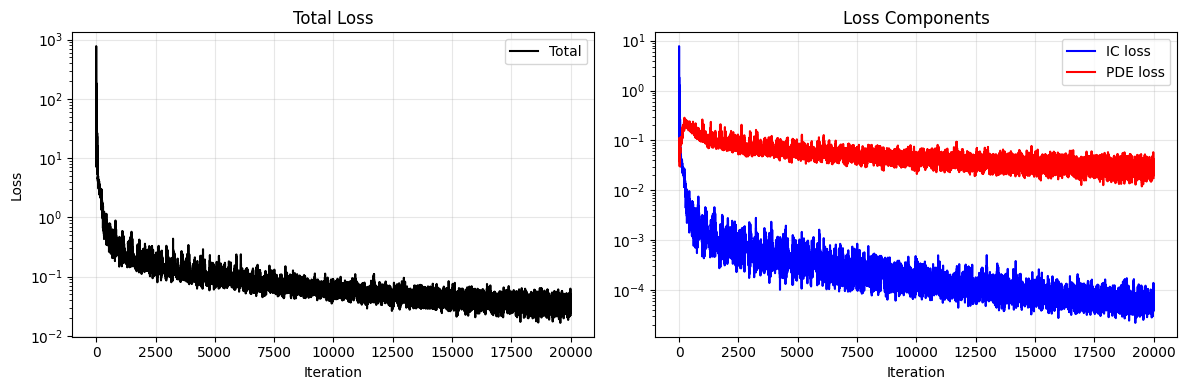

[plot] Salvato: /content/drive/MyDrive/pinn-turbulence-results/causal/baseline_velocity.png


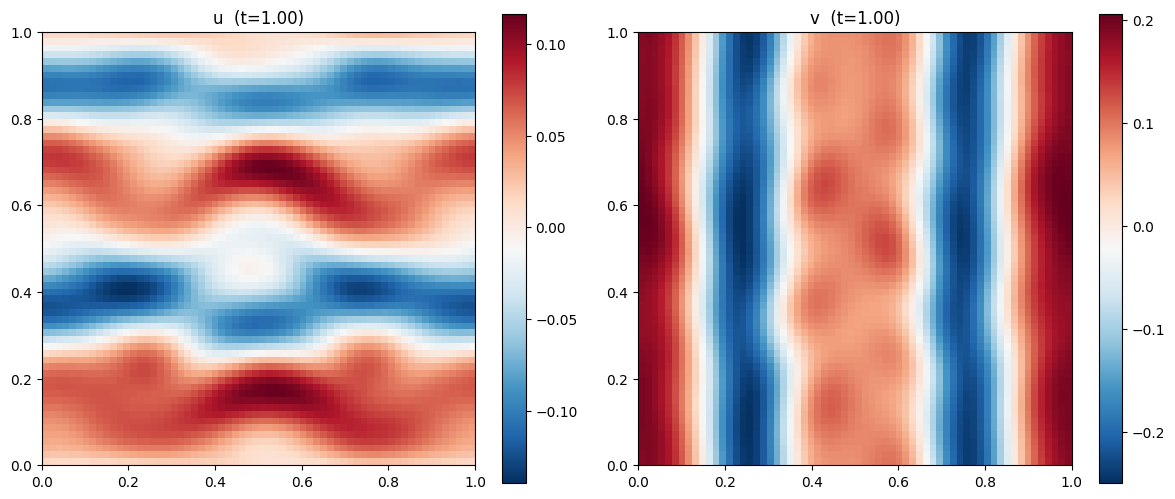

[checkpoint] Salvato: /content/drive/MyDrive/pinn-turbulence-results/causal/weights/baseline_final.pt


In [10]:
# ── CELLA 5: Lancia il training ───────────────────────────────
import sys
sys.path.insert(0, '/content/pinn-turbolence')

from src.training import train, load_config

CAUSAL_CONFIG = "configs/kolmogorov_causal.yaml"

cfg = load_config(CAUSAL_CONFIG)

# Cartella dedicata su Google Drive
cfg["results_dir"] = DRIVE_DIR + "/causal"

model, history = train(
    cfg,
    cfg_path=CAUSAL_CONFIG
)

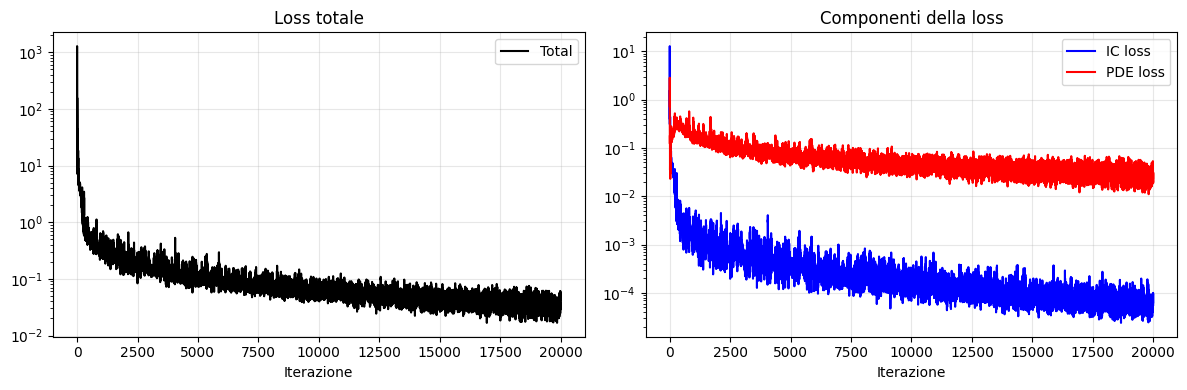

Grafico salvato su Drive.


In [ ]:
# ── CELLA 6: Visualizza risultati ────────────────────────────
# (esegui questa cella dopo che il training e' finito)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history['total'], color='black', label='Total')
axes[0].set_title('Loss totale')
axes[0].set_xlabel('Iterazione')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(history['ic'],  color='blue',  label='IC loss')
axes[1].semilogy(history['pde'], color='red',   label='PDE loss')
axes[1].set_title('Componenti della loss')
axes[1].set_xlabel('Iterazione')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(DRIVE_DIR + '/baseline_loss.png', dpi=150)
plt.show()
print(f"Grafico salvato su Drive.")